## 1. Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)

In [2]:
df = pd.read_csv("../data/processed/cars_processed.csv")
df.head()

,Brand,Model,Year,Fuel,Transmission,Km,Owner,Price,Location,Engine,Seats
0,Honda,Amaze 1.2 VX i-VTEC,2017,Petrol,Manual,87150,First,505000.0,Pune,1198,5.0
1,Maruti Suzuki,Swift DZire VDI,2014,Diesel,Manual,75000,Second,450000.0,Ludhiana,1248,5.0
2,Hyundai,i10 Magna 1.2 Kappa2,2011,Petrol,Manual,67000,First,220000.0,Lucknow,1197,5.0
3,Toyota,Glanza G,2019,Petrol,Manual,37500,First,799000.0,Mangalore,1197,5.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],2018,Diesel,Manual,69000,First,1950000.0,Mumbai,2393,7.0


In [3]:
df.isnull().sum()

Brand           0
Model           0
Year            0
Fuel            0
Transmission    0
Km              0
Owner           0
Price           0
Location        0
Engine          0
Seats           0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7956 entries, 0 to 7955
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         7956 non-null   object 
 1   Model         7956 non-null   object 
 2   Year          7956 non-null   int64  
 3   Fuel          7956 non-null   object 
 4   Transmission  7956 non-null   object 
 5   Km            7956 non-null   int64  
 6   Owner         7956 non-null   object 
 7   Price         7956 non-null   float64
 8   Location      7956 non-null   object 
 9   Engine        7956 non-null   int64  
 10  Seats         7956 non-null   float64
dtypes: float64(2), int64(3), object(6)
memory usage: 683.8+ KB


In [5]:
df['Brand'].value_counts()

Brand
Hyundai          1442
Maruti           1197
Honda             751
Toyota            540
Mercedes-Benz     481
Maruti Suzuki     426
Mahindra          390
BMW               381
Volkswagen        357
Audi              355
Ford              346
Tata              237
Skoda             210
Renault           188
Chevrolet         128
Nissan            106
Land               57
Jaguar             53
Volvo              37
Land Rover         32
Jeep               31
Mitsubishi         31
Porsche            30
Fiat               27
Mini               26
Kia                23
Datsun             21
MG                 16
MINI               11
Lexus               5
Isuzu               3
Rolls-Royce         3
Ssangyong           3
Force               3
ISUZU               2
Lamborghini         2
Maserati            1
Ferrari             1
Smart               1
Ambassador          1
Bentley             1
Name: count, dtype: int64

In [6]:
df['Brand'] = df['Brand'].replace({
    'Maruti': 'Maruti Suzuki',
    'Land': 'Land Rover',
    'MINI': 'Mini'
})
brand_counts = df['Brand'].value_counts()
valid_brands = brand_counts[brand_counts >= 100].index
df = df[df['Brand'].isin(valid_brands)]
df['Brand'].value_counts()

Brand
Maruti Suzuki    1623
Hyundai          1442
Honda             751
Toyota            540
Mercedes-Benz     481
Mahindra          390
BMW               381
Volkswagen        357
Audi              355
Ford              346
Tata              237
Skoda             210
Renault           188
Chevrolet         128
Nissan            106
Name: count, dtype: int64

In [7]:
df.shape

(7535, 11)

In [8]:
print(df['Model'].value_counts())

Model
XUV500 W8 2WD                                              49
Swift VDI                                                  45
City 1.5 S MT                                              43
Swift Dzire VDI                                            34
Swift VDI BSIV                                             31
i10 Sportz                                                 30
Ritz VDi                                                   30
Fortuner 3.0 Diesel                                        29
Brio S MT                                                  29
City 1.5 V MT                                              29
Wagon R VXI                                                29
Grand i10 Sportz                                           27
Amaze S i-Dtech                                            27
Ertiga VDI                                                 25
Wagon R LXI CNG                                            24
Verna 1.6 SX                                               23
Wa

### Extract Base Model

In [9]:
df['Model_Base'] = df['Model'].str.split().str[0]
print(df['Model_Base'].value_counts())
print(f"\nUnique models after 1 word: {df['Model_Base'].nunique()}")

Model_Base
Swift        440
City         347
i20          268
Verna        216
Innova       211
Wagon        206
Grand        205
Alto         194
i10          188
Polo         173
Creta        163
Fortuner     145
XUV500       143
Amaze        133
Vento        121
E-Class      119
Figo         108
Ciaz         104
New          102
Ertiga       100
A4            98
3             98
Duster        98
Baleno        96
Scorpio       96
Santro        88
Celerio       85
Corolla       83
Vitara        81
A6            73
Jazz          73
Ritz          73
Ecosport      73
Etios         72
Xcent         70
Brio          68
5             63
Rapid         62
EON           61
Superb        58
Elite         58
X1            54
Q3            53
Q7            53
Endeavour     50
Beat          47
X5            44
Fiesta        42
EcoSport      42
Octavia       41
KWID          40
SX4           40
Indica        40
Q5            37
C-Class       36
Terrano       35
Micra         34
Civic         34
5-S

In [10]:
# Find potential duplicates — models that are similar but not identical
from collections import Counter

model_counts = df['Model_Base'].value_counts()

# Normalize — lowercase, remove hyphens/spaces for comparison
df['Model_Normalized'] = (df['Model_Base']
                          .str.lower()
                          .str.replace('-', '')
                          .str.replace(' ', '')
                          .str.strip())

# Show groups that normalize to the same string
normalized_counts = df.groupby('Model_Normalized')['Model_Base'].unique()
duplicates = normalized_counts[normalized_counts.apply(len) > 1]
print("Potential duplicate groups:")
for norm, variants in duplicates.items():
    counts = {v: model_counts.get(v, 0) for v in variants}
    print(f"  {norm}: {counts}")

Potential duplicate groups:
  brv: {'BR-V': np.int64(4), 'BRV': np.int64(5)}
  dzire: {'DZire': np.int64(18), 'Dzire': np.int64(24)}
  ecosport: {'Ecosport': np.int64(73), 'EcoSport': np.int64(42)}
  eon: {'Eon': np.int64(17), 'EON': np.int64(61)}
  kwid: {'Kwid': np.int64(24), 'KWID': np.int64(40)}
  wrv: {'WR-V': np.int64(10), 'WRV': np.int64(4)}


In [11]:
# For each duplicate group, keep the variant with higher count
model_counts = df['Model_Base'].value_counts()

duplicate_groups = df.groupby('Model_Normalized')['Model_Base'].unique()
duplicate_groups = duplicate_groups[duplicate_groups.apply(len) > 1]

replace_map = {}
for norm, variants in duplicate_groups.items():
    # Keep the variant with the highest count
    canonical = max(variants, key=lambda v: model_counts.get(v, 0))
    for variant in variants:
        if variant != canonical:
            replace_map[variant] = canonical

print("Replacing:")
for k, v in replace_map.items():
    print(f"  '{k}' → '{v}'")

df['Model_Base'] = df['Model_Base'].replace(replace_map)
df.drop(columns=['Model_Normalized'], inplace=True)

print(f"\nUnique Model_Base after fix: {df['Model_Base'].nunique()}")
print(df['Model_Base'].value_counts())

Replacing:
  'BR-V' → 'BRV'
  'DZire' → 'Dzire'
  'EcoSport' → 'Ecosport'
  'Eon' → 'EON'
  'Kwid' → 'KWID'
  'WRV' → 'WR-V'

Unique Model_Base after fix: 207
Model_Base
Swift        440
City         347
i20          268
Verna        216
Innova       211
Wagon        206
Grand        205
Alto         194
i10          188
Polo         173
Creta        163
Fortuner     145
XUV500       143
Amaze        133
Vento        121
E-Class      119
Ecosport     115
Figo         108
Ciaz         104
New          102
Ertiga       100
A4            98
Duster        98
3             98
Scorpio       96
Baleno        96
Santro        88
Celerio       85
Corolla       83
Vitara        81
EON           78
Jazz          73
A6            73
Ritz          73
Etios         72
Xcent         70
Brio          68
KWID          64
5             63
Rapid         62
Elite         58
Superb        58
X1            54
Q3            53
Q7            53
Endeavour     50
Beat          47
X5            44
Dzire         

In [12]:
df.shape

(7535, 12)

In [13]:
df['Model_Base'] = df.apply(lambda row:
    'Grand i10'     if row['Brand'] == 'Hyundai'       and row['Model_Base'] == 'Grand'  else
    'Grand Vitara'  if row['Brand'] == 'Maruti Suzuki' and row['Model_Base'] == 'Grand'  else
    'C-Class'       if row['Brand'] == 'Mercedes-Benz' and row['Model_Base'] == 'New'    else
    'Safari'        if row['Brand'] == 'Tata'          and row['Model_Base'] == 'New'    else
    'Wagon R'       if row['Model_Base'] == 'Wagon'    else
    'Vitara Brezza' if row['Model_Base'] == 'Vitara'   else
    '3 Series'      if row['Model_Base'] == '3'        else
    row['Model_Base']
, axis=1)
df = df[df['Model_Base'] != 'New']

print(df['Model_Base'].value_counts().head(20))
print(f"\nShape after: {df.shape}")

Model_Base
Swift        440
City         347
i20          268
Verna        216
Innova       211
Wagon R      206
Grand i10    200
Alto         194
i10          188
Polo         173
Creta        163
Fortuner     145
XUV500       143
Amaze        133
C-Class      130
Vento        121
E-Class      119
Ecosport     115
Figo         108
Ciaz         104
Name: count, dtype: int64

Shape after: (7535, 12)


In [14]:
model_counts = df['Model_Base'].value_counts()
valid_models = model_counts[model_counts >= 75].index
df = df[df['Model_Base'].isin(valid_models)]

print(df['Model_Base'].value_counts())
print(f"\nShape after: {df.shape}")

Model_Base
Swift            440
City             347
i20              268
Verna            216
Innova           211
Wagon R          206
Grand i10        200
Alto             194
i10              188
Polo             173
Creta            163
Fortuner         145
XUV500           143
Amaze            133
C-Class          130
Vento            121
E-Class          119
Ecosport         115
Figo             108
Ciaz             104
Ertiga           100
A4                98
Duster            98
3 Series          98
Scorpio           96
Baleno            96
Santro            88
Celerio           85
Corolla           83
Vitara Brezza     81
EON               78
Name: count, dtype: int64

Shape after: (4725, 12)


In [15]:
df['Year'].value_counts()

Year
2014    646
2015    603
2016    573
2017    491
2013    479
2012    388
2011    322
2018    314
2010    218
2019    173
2009    135
2008    100
2007     60
2021     49
2020     42
2006     41
2005     32
2022     31
2004     13
2002      5
2003      4
2001      3
1988      1
1999      1
1998      1
Name: count, dtype: int64

In [16]:
df = df[df['Year'] >= 2004]

print(df['Year'].value_counts().sort_index())
print(f"\nShape after: {df.shape}")

Year
2004     13
2005     32
2006     41
2007     60
2008    100
2009    135
2010    218
2011    322
2012    388
2013    479
2014    646
2015    603
2016    573
2017    491
2018    314
2019    173
2020     42
2021     49
2022     31
Name: count, dtype: int64

Shape after: (4710, 12)


In [17]:
df['Fuel'].value_counts()

Fuel
Petrol          2309
Diesel          2298
CNG               86
LPG               15
CNG + CNG          1
Petrol + CNG       1
Name: count, dtype: int64

In [18]:
df['Fuel'] = df['Fuel'].replace({
    'CNG + CNG':    'CNG',
    'Petrol + CNG': 'CNG',
})

df = df[df['Fuel'] != 'LPG']

print(df['Fuel'].value_counts())
print(f"\nShape after: {df.shape}")

Fuel
Petrol    2309
Diesel    2298
CNG         88
Name: count, dtype: int64

Shape after: (4695, 12)


In [19]:
df['Transmission'].value_counts()

Transmission
Manual       3636
Automatic    1059
Name: count, dtype: int64

In [20]:
print(df['Km'].describe())

count    4.695000e+03
mean     5.741886e+04
std      4.770606e+04
min      1.000000e+00
25%      3.461650e+04
50%      5.300000e+04
75%      7.199650e+04
max      2.000000e+06
Name: Km, dtype: float64


In [21]:
df = df[(df['Km'] >= 500) & (df['Km'] <= 500000)]

print(df['Km'].describe())
print(f"\nShape after: {df.shape}")

count      4689.000000
mean      56582.716357
std       33911.785268
min         500.000000
25%       34620.000000
50%       53000.000000
75%       71904.000000
max      480000.000000
Name: Km, dtype: float64

Shape after: (4689, 12)


In [22]:
print(df['Owner'].value_counts())

Owner
First               3907
Second               713
Third                 59
UnRegistered Car       5
Fourth & Above         4
Fourth                 1
Name: count, dtype: int64


In [23]:
df['Owner'] = df['Owner'].replace({'Fourth': 'Fourth & Above'})
df = df[~df['Owner'].isin(['UnRegistered Car', 'Fourth & Above'])]

owner_map = {'First': 1, 'Second': 2, 'Third': 3}
df['Owner'] = df['Owner'].map(owner_map)

print(df['Owner'].value_counts())
print(f"\nShape after: {df.shape}")

Owner
1    3907
2     713
3      59
Name: count, dtype: int64

Shape after: (4679, 12)


In [24]:
print(df['Price'].describe())
print(f"\nTop 5 highest:\n{df['Price'].nlargest(5)}")
print(f"\nBottom 5 lowest:\n{df['Price'].nsmallest(5)}")

count    4.679000e+03
mean     8.058230e+05
std      7.860851e+05
min      7.500000e+04
25%      3.800000e+05
50%      5.750000e+05
75%      8.950000e+05
max      7.880000e+06
Name: Price, dtype: float64

Top 5 highest:
4285    7880000.0
432     7780000.0
238     7500000.0
474     7500000.0
830     7475000.0
Name: Price, dtype: float64

Bottom 5 lowest:
7913    75000.0
2623    80000.0
2099    85000.0
6289    85000.0
7580    85000.0
Name: Price, dtype: float64


In [25]:
print(df['Location'].value_counts())

Location
Mumbai              618
Delhi               513
Hyderabad           489
Pune                416
Kochi               408
Kolkata             394
Coimbatore          372
Chennai             296
Bangalore           279
Jaipur              271
Ahmedabad           177
Lucknow              48
Kanpur               36
Patna                33
Ludhiana             28
Mohali               24
Ranchi               17
Faridabad            17
Gurgaon              16
Jalandhar            15
Varanasi             15
Agra                 14
Dehradun             14
Noida                12
Chandigarh           12
Thane                11
Navi Mumbai          11
Jamshedpur           10
Zirakpur              8
Meerut                8
Raipur                7
Surat                 6
Salem                 5
Udupi                 5
Mysore                4
Ambala Cantt          4
Guwahati              4
Mangalore             3
Allahabad             3
Nashik                3
Roorkee               3
Dharwad

In [26]:
# Consolidate metro areas
df['Location'] = df['Location'].replace({
    'Navi Mumbai':       'Mumbai',
    'Thane':             'Mumbai',
    'Gurgaon':           'Delhi',
    'Noida':             'Delhi',
    'Faridabad':         'Delhi',
    'Mohali':            'Chandigarh',
    'Zirakpur':          'Chandigarh',
    'Panchkula':         'Chandigarh',
    'Pimpri-Chinchwad':  'Pune',
    'Ernakulam':         'Kochi',
    'Kollam':            'Kochi',
    'Ranga Reddy':       'Hyderabad',
    'Warangal':          'Hyderabad',
    'Dak. Kannada':      'Mangalore',
})

print(df['Location'].value_counts())
print(f"\nShape after: {df.shape}")

Location
Mumbai          640
Delhi           558
Hyderabad       492
Pune            417
Kochi           412
Kolkata         394
Coimbatore      372
Chennai         296
Bangalore       279
Jaipur          271
Ahmedabad       177
Lucknow          48
Chandigarh       46
Kanpur           36
Patna            33
Ludhiana         28
Ranchi           17
Jalandhar        15
Varanasi         15
Agra             14
Dehradun         14
Jamshedpur       10
Meerut            8
Raipur            7
Surat             6
Salem             5
Udupi             5
Mysore            4
Guwahati          4
Ambala Cantt      4
Mangalore         4
Rudrapur          3
Allahabad         3
Dharwad           3
Aurangabad        3
Yamunanagar       3
Nashik            3
Roorkee           3
Amritsar          2
Ghaziabad         2
Bhopal            2
Muzaffurpur       2
Karnal            2
Purnea            2
Samastipur        2
Nagpur            2
Indore            2
Vadodara          1
Rohtak            1
Deoghar    

In [27]:
city_counts = df['Location'].value_counts()
valid_cities = city_counts[city_counts >= 50].index
df = df[df['Location'].isin(valid_cities)]

In [28]:
print(df['Location'].value_counts())

Location
Mumbai        640
Delhi         558
Hyderabad     492
Pune          417
Kochi         412
Kolkata       394
Coimbatore    372
Chennai       296
Bangalore     279
Jaipur        271
Ahmedabad     177
Name: count, dtype: int64


In [29]:
print(df['Engine'].describe())
print(df['Engine'].value_counts().head(10))

count    4308.000000
mean     1516.644383
std       496.238556
min       793.000000
25%      1197.000000
50%      1396.000000
75%      1598.000000
max      3498.000000
Name: Engine, dtype: float64
Engine
1197    635
1248    421
998     291
1497    274
1498    260
2179    178
1582    155
1591    134
2494    119
1198    117
Name: count, dtype: int64


In [30]:
print(df['Seats'].value_counts())

Seats
5.0    3679
7.0     492
8.0     117
4.0      18
9.0       1
0.0       1
Name: count, dtype: int64


In [31]:
df = df[~df['Seats'].isin([0.0, 9.0])]

print(df['Seats'].value_counts())
print(f"\nShape after: {df.shape}")

Seats
5.0    3679
7.0     492
8.0     117
4.0      18
Name: count, dtype: int64

Shape after: (4306, 12)


In [32]:
df.head()

,Brand,Model,Year,Fuel,Transmission,Km,Owner,Price,Location,Engine,Seats,Model_Base
0,Honda,Amaze 1.2 VX i-VTEC,2017,Petrol,Manual,87150,1,505000.0,Pune,1198,5.0,Amaze
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],2018,Diesel,Manual,69000,1,1950000.0,Mumbai,2393,7.0,Innova
5,Maruti Suzuki,Ciaz ZXi,2017,Petrol,Manual,73315,1,675000.0,Pune,1373,5.0,Ciaz
12,Maruti Suzuki,Ciaz Alpha Hybrid 1.5 AT [2018-2020],2019,Petrol,Automatic,30672,1,1075000.0,Bangalore,1462,5.0,Ciaz
14,Volkswagen,Polo GT TSI,2017,Petrol,Automatic,41417,1,944999.0,Bangalore,1197,5.0,Polo


In [33]:
df.drop(columns=['Model'], inplace=True)
df.head()

,Brand,Year,Fuel,Transmission,Km,Owner,Price,Location,Engine,Seats,Model_Base
0,Honda,2017,Petrol,Manual,87150,1,505000.0,Pune,1198,5.0,Amaze
4,Toyota,2018,Diesel,Manual,69000,1,1950000.0,Mumbai,2393,7.0,Innova
5,Maruti Suzuki,2017,Petrol,Manual,73315,1,675000.0,Pune,1373,5.0,Ciaz
12,Maruti Suzuki,2019,Petrol,Automatic,30672,1,1075000.0,Bangalore,1462,5.0,Ciaz
14,Volkswagen,2017,Petrol,Automatic,41417,1,944999.0,Bangalore,1197,5.0,Polo


## 2. Exploratory Data Analysis

### Price Distribution

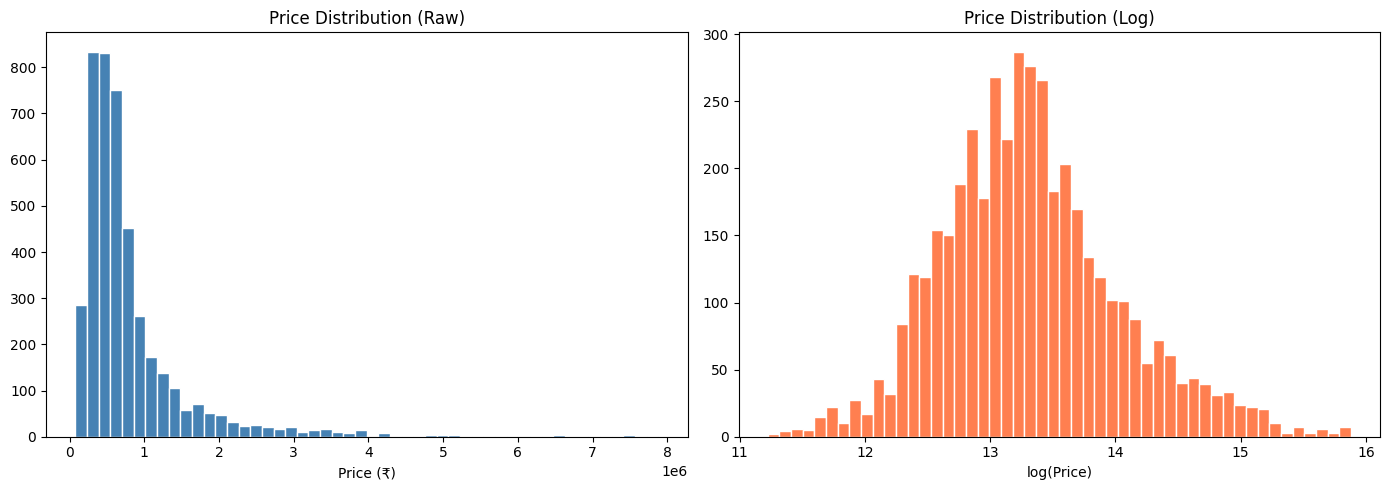

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Raw price
axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)')
axes[0].set_xlabel('Price (₹)')

# Log price — better for skewed data
axes[1].hist(np.log1p(df['Price']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Price Distribution (Log)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
fig.savefig('../reports/price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Price by Fuel type

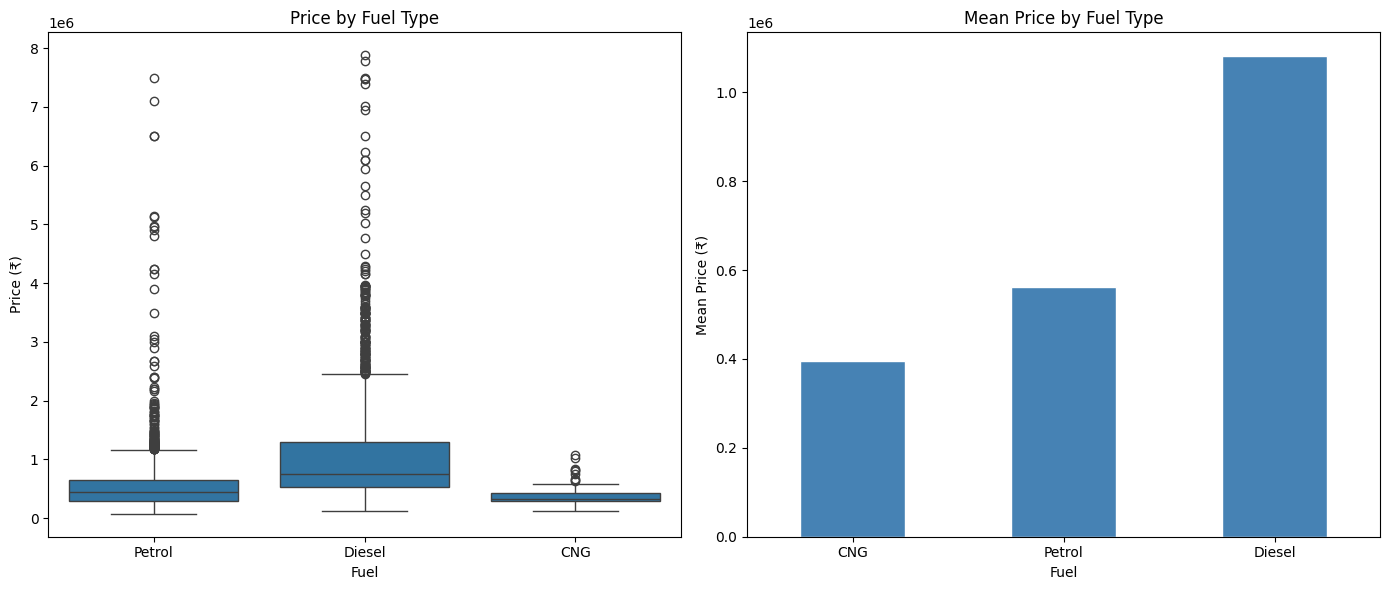

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  

# Boxplot
sns.boxplot(data=df, x='Fuel', y='Price', ax=axes[0])
axes[0].set_title('Price by Fuel Type')
axes[0].set_ylabel('Price (₹)')

# Mean price bar
df.groupby('Fuel')['Price'].mean().sort_values().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Mean Price by Fuel Type')
axes[1].set_ylabel('Mean Price (₹)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig.savefig('../reports/price_by_fuel.png', dpi=300, bbox_inches='tight')
plt.show()

### Price By Transmission

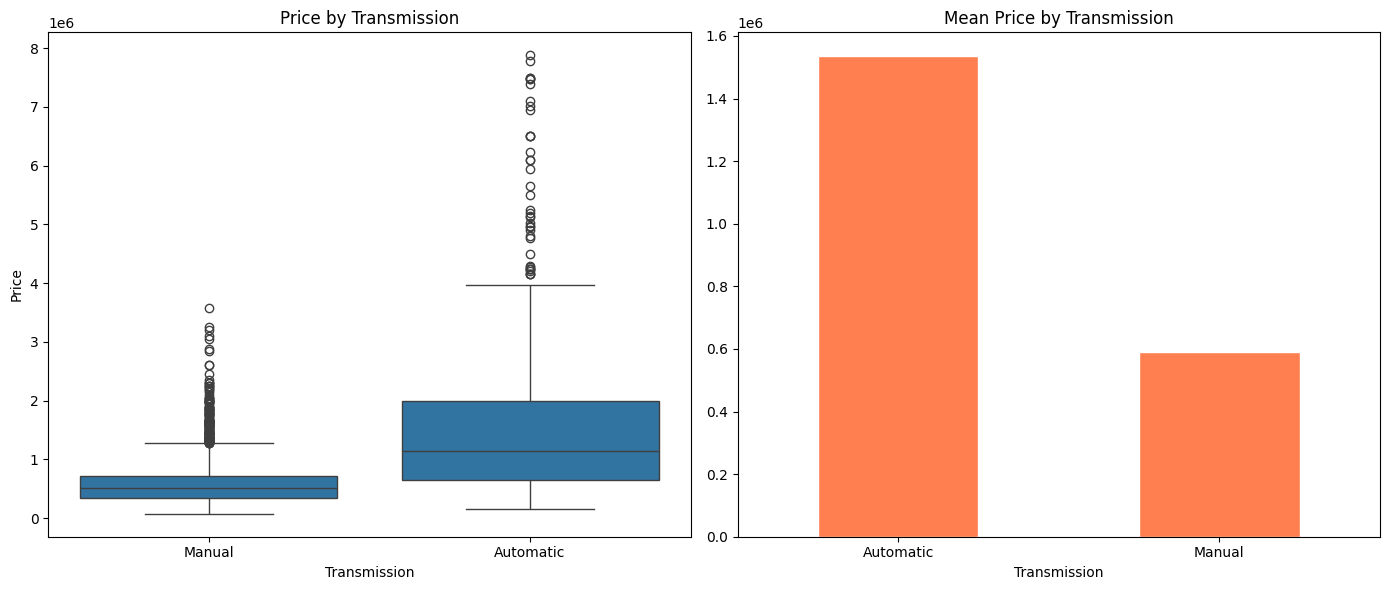

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

sns.boxplot(data=df, x='Transmission', y='Price', ax=axes[0])
axes[0].set_title('Price by Transmission')

df.groupby('Transmission')['Price'].mean().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white'
)
axes[1].set_title('Mean Price by Transmission')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig.savefig('../reports/price_by_transmission.png', dpi=300, bbox_inches='tight')
plt.show()

### Price By Owner

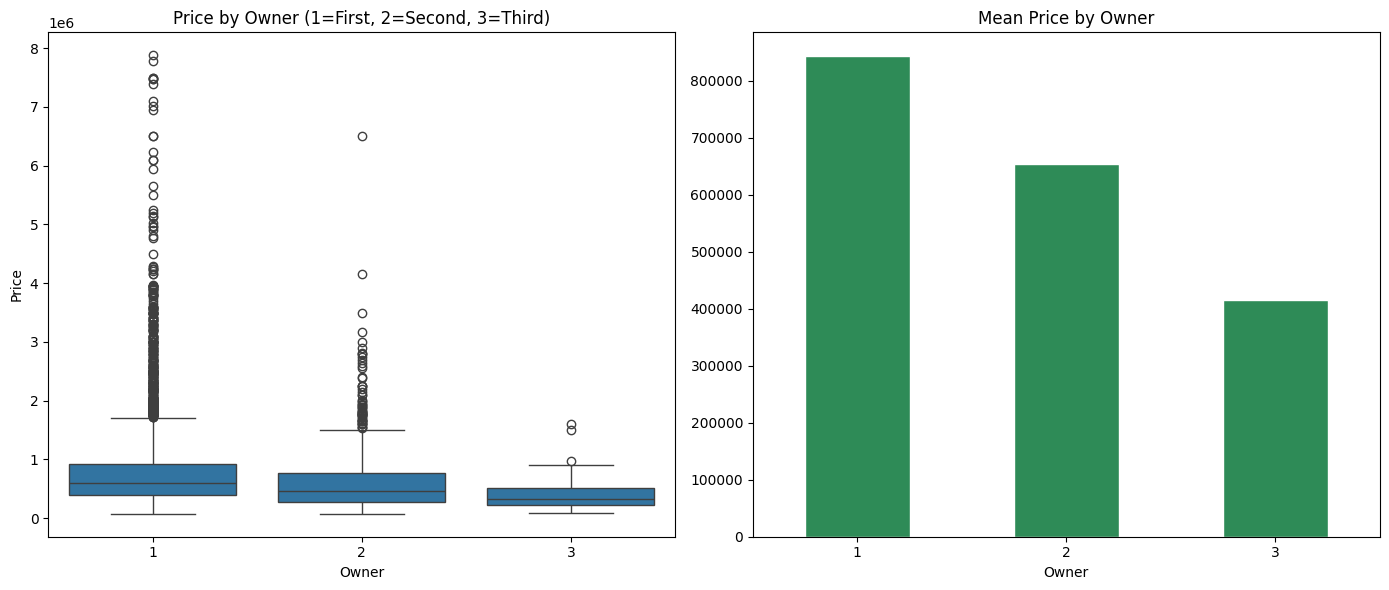

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 

sns.boxplot(data=df, x='Owner', y='Price', ax=axes[0])
axes[0].set_title('Price by Owner (1=First, 2=Second, 3=Third)')

df.groupby('Owner')['Price'].mean().plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='white'
)
axes[1].set_title('Mean Price by Owner')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
fig.savefig('../reports/price_by_owner.png', dpi=300, bbox_inches='tight')
plt.show()

### Price vs Km

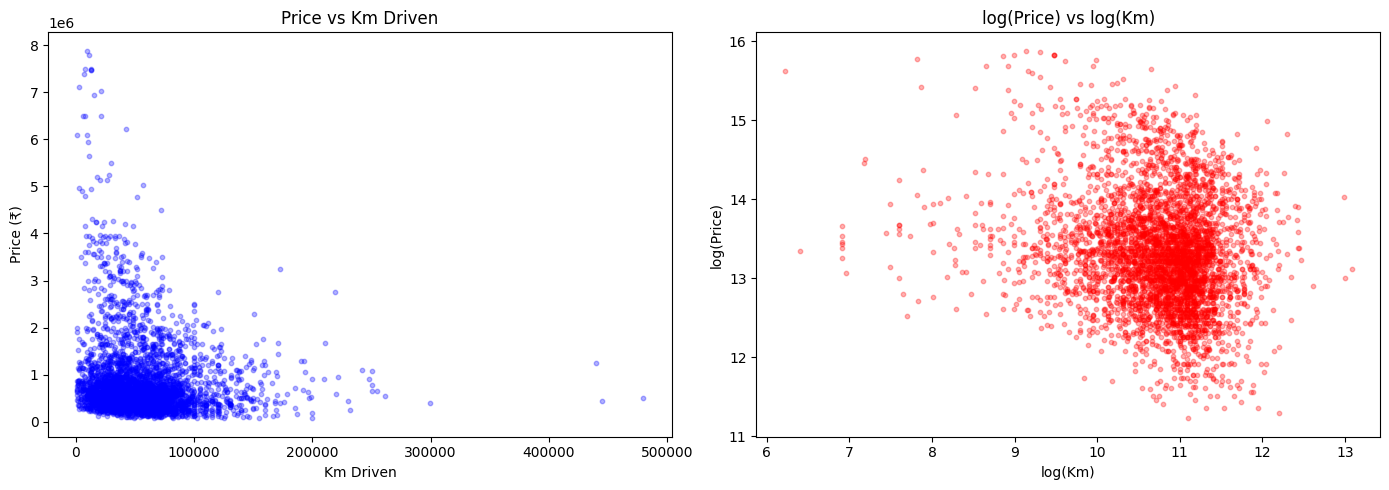

Correlation (Price vs Km): -0.141


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 

axes[0].scatter(df['Km'], df['Price'], alpha=0.3, color='blue', s=10)
axes[0].set_title('Price vs Km Driven')
axes[0].set_xlabel('Km Driven')
axes[0].set_ylabel('Price (₹)')

# Log scale — cleaner view
axes[1].scatter(np.log1p(df['Km']), np.log1p(df['Price']),
                alpha=0.3, color='red', s=10)
axes[1].set_title('log(Price) vs log(Km)')
axes[1].set_xlabel('log(Km)')
axes[1].set_ylabel('log(Price)')

plt.tight_layout()
fig.savefig('../reports/price_vs_km.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Correlation (Price vs Km): {df['Price'].corr(df['Km']):.3f}")

### Price Vs Year

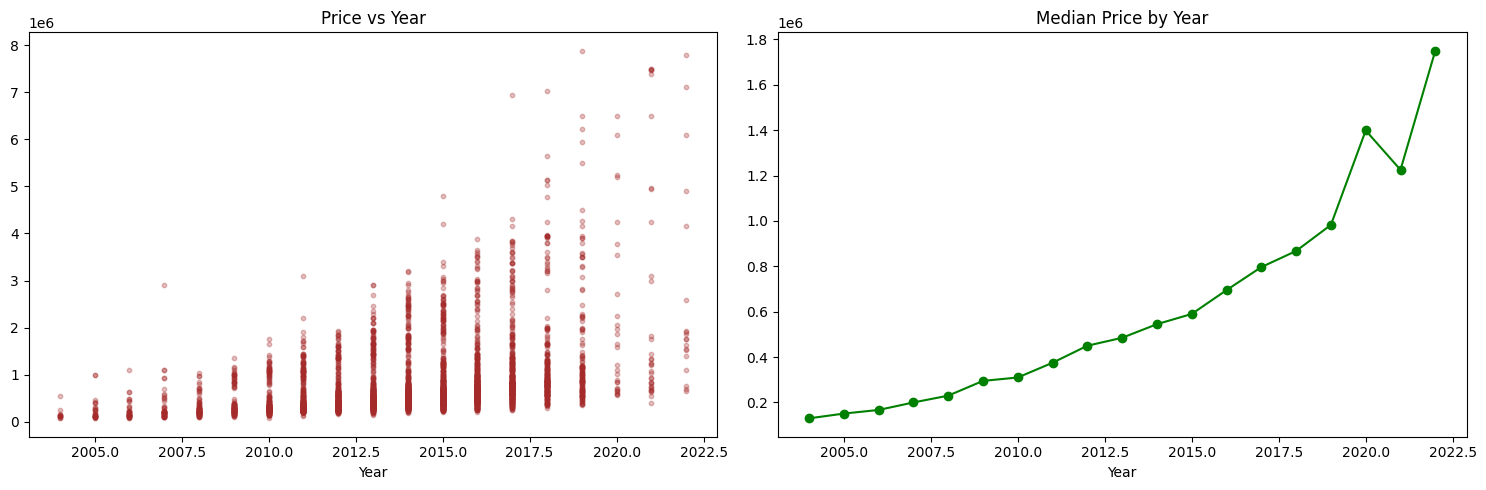

Correlation (Price vs Year): 0.392


In [39]:
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

axes[0].scatter(df['Year'], df['Price'], alpha=0.3, color='brown', s=10)
axes[0].set_title('Price vs Year')
axes[0].set_xlabel('Year')

df.groupby('Year')['Price'].median().plot(
    ax=axes[1], color='green', marker='o'
)
axes[1].set_title('Median Price by Year')
axes[1].set_xlabel('Year')

plt.tight_layout()
fig.savefig('../reports/price_vs_year.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Correlation (Price vs Year): {df['Price'].corr(df['Year']):.3f}")

### Price By Location

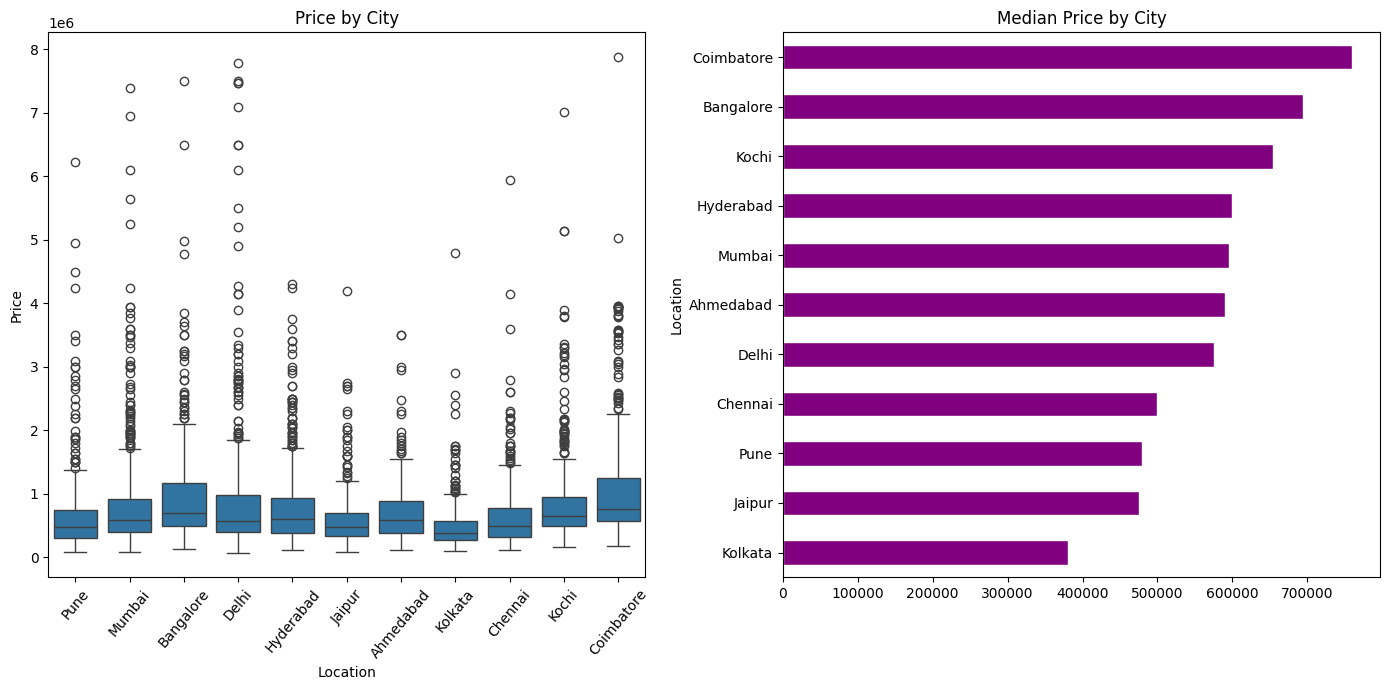

In [40]:
import os

# Create folder if it doesn't exist
os.makedirs('../reports', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

sns.boxplot(data=df, x='Location', y='Price', ax=axes[0])
axes[0].set_title('Price by City')
axes[0].tick_params(axis='x', rotation=50)

df.groupby('Location')['Price'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='purple', edgecolor='white'
)
axes[1].set_title('Median Price by City')

plt.tight_layout()

# Save the figure
fig.savefig('../reports/price_by_location.png', dpi=300, bbox_inches='tight')

plt.show()

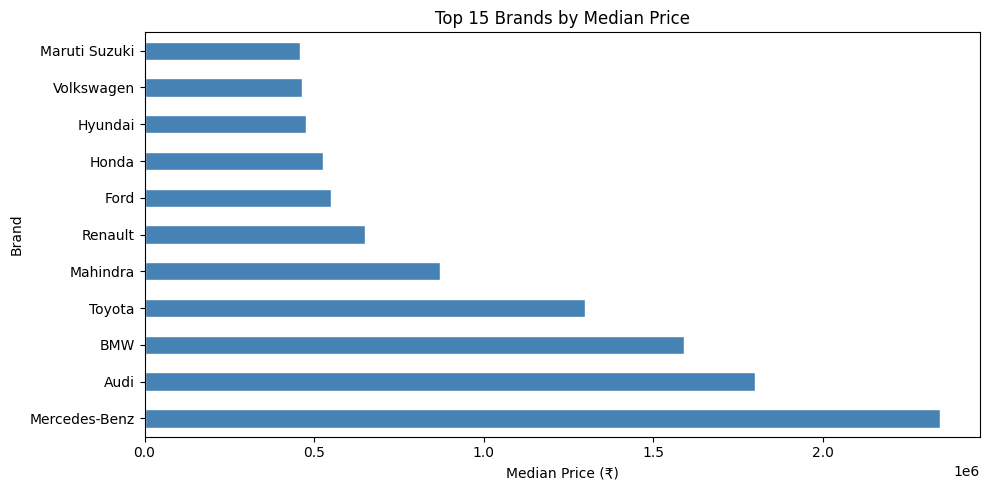

In [41]:
top_brands = df.groupby('Brand')['Price'].median().sort_values(ascending=False).head(15)

top_brands.plot(kind='barh', color='steelblue', edgecolor='white', figsize=(10, 5))
plt.title('Top 15 Brands by Median Price')
plt.xlabel('Median Price (₹)')
plt.tight_layout()
plt.show()

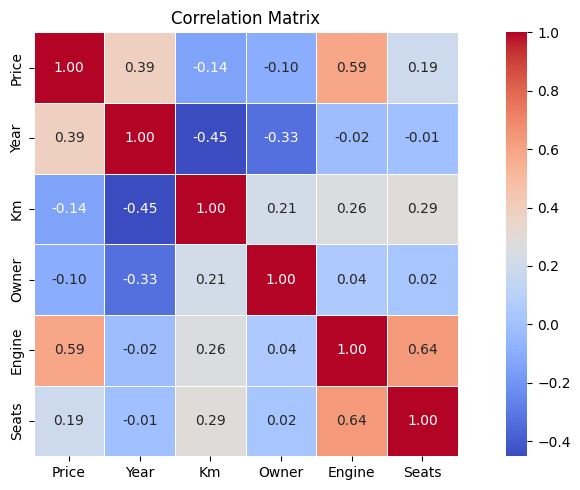

In [42]:
num_cols = ['Price', 'Year', 'Km', 'Owner', 'Engine', 'Seats']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Pre Processing

In [43]:
import json

df['Car_Age']     = 2024 - df['Year']
df['Km_Per_Year'] = df['Km'] / df['Car_Age'].replace(0, 1)
df['Log_Price']   = np.log1p(df['Price'])

brand_model_map = (
    df.groupby('Brand')['Model_Base']
    .unique()
    .apply(sorted)
    .to_dict()
)

with open('../models/brand_model_map.json', 'w') as f:
    json.dump(brand_model_map, f, indent=2)

print("Brand-model map saved.")
print(json.dumps(brand_model_map, indent=2))
print(df[['Car_Age', 'Km_Per_Year', 'Log_Price']].describe())

Brand-model map saved.
{
  "Audi": [
    "A4"
  ],
  "BMW": [
    "3 Series"
  ],
  "Ford": [
    "Ecosport",
    "Figo"
  ],
  "Honda": [
    "Amaze",
    "City"
  ],
  "Hyundai": [
    "Creta",
    "EON",
    "Grand i10",
    "Santro",
    "Verna",
    "i10",
    "i20"
  ],
  "Mahindra": [
    "Scorpio",
    "XUV500"
  ],
  "Maruti Suzuki": [
    "Alto",
    "Baleno",
    "Celerio",
    "Ciaz",
    "Ertiga",
    "Swift",
    "Vitara Brezza",
    "Wagon R"
  ],
  "Mercedes-Benz": [
    "C-Class",
    "E-Class"
  ],
  "Renault": [
    "Duster"
  ],
  "Toyota": [
    "Corolla",
    "Fortuner",
    "Innova"
  ],
  "Volkswagen": [
    "Polo",
    "Vento"
  ]
}
           Car_Age   Km_Per_Year    Log_Price
count  4306.000000   4306.000000  4306.000000
mean      9.970274   5670.148487    13.319893
std       3.119166   3274.108120     0.711734
min       2.000000    111.222222    11.225257
25%       8.000000   3658.337662    12.847929
50%      10.000000   5212.462500    13.262127
75%      12.

In [44]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
for col in ['Brand', 'Model_Base', 'Location']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df = pd.get_dummies(df, columns=['Fuel', 'Transmission'], drop_first=True, dtype=int)
df.head()

,Brand,Year,Km,Owner,Price,Location,Engine,Seats,Model_Base,Car_Age,Km_Per_Year,Log_Price,Fuel_Diesel,Fuel_Petrol,Transmission_Manual
0,3,2017,87150,1,505000.0,10,1198,5.0,3,7,12450.000000,13.132316,0,1,1
4,9,2018,69000,1,1950000.0,9,2393,7.0,19,6,11500.000000,14.483340,1,0,1
5,6,2017,73315,1,675000.0,10,1373,5.0,7,7,10473.571429,13.422469,0,1,1
12,6,2019,30672,1,1075000.0,1,1462,5.0,7,5,6134.400000,13.887832,0,1,0
14,10,2017,41417,1,944999.0,1,1197,5.0,20,7,5916.714286,13.758940,0,1,0


In [45]:
df = df.rename(columns={
    'Car_Age': 'Car Age',
    'Km_Per_Year': 'Km Per Year',
    'Log_Price': 'Log Price',
    'Fuel_Diesel':'Diesel',
    'Fuel_Petrol': 'Petrol',
    'Transmission_Manual': 'Manual Transmission',
    'Model_Base': 'Base Model'
})

In [46]:
df.head()

,Brand,Year,Km,Owner,Price,Location,Engine,Seats,Base Model,Car Age,Km Per Year,Log Price,Diesel,Petrol,Manual Transmission
0,3,2017,87150,1,505000.0,10,1198,5.0,3,7,12450.000000,13.132316,0,1,1
4,9,2018,69000,1,1950000.0,9,2393,7.0,19,6,11500.000000,14.483340,1,0,1
5,6,2017,73315,1,675000.0,10,1373,5.0,7,7,10473.571429,13.422469,0,1,1
12,6,2019,30672,1,1075000.0,1,1462,5.0,7,5,6134.400000,13.887832,0,1,0
14,10,2017,41417,1,944999.0,1,1197,5.0,20,7,5916.714286,13.758940,0,1,0


### Model Training

In [47]:
X = df.drop(columns=['Price', 'Year', 'Log Price'])
Y = df['Log Price']
X.shape, Y.shape

((4306, 12), (4306,))

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)
X_train.shape, X_test.shape

((3014, 12), (1292, 12))

In [50]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.67598
[100]	validation_0-rmse:0.15381
[200]	validation_0-rmse:0.14558
[300]	validation_0-rmse:0.14407
[400]	validation_0-rmse:0.14383
[499]	validation_0-rmse:0.14376


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(Y_test)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE:  ₹{mae:,.0f}")
print(f"RMSE: ₹{rmse:,.0f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE:  ₹86,446
RMSE: ₹173,132
R²:   0.9519
MAPE: 10.31%


In [52]:
# 1. Add early stopping to avoid overfitting
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=100
)

[0]	validation_0-rmse:0.67598
[100]	validation_0-rmse:0.15381
[200]	validation_0-rmse:0.14558
[300]	validation_0-rmse:0.14407
[400]	validation_0-rmse:0.14383
[455]	validation_0-rmse:0.14386


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [53]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(Y_test)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE:  ₹{mae:,.0f}")
print(f"RMSE: ₹{rmse:,.0f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE:  ₹86,862
RMSE: ₹174,337
R²:   0.9512
MAPE: 10.31%


In [54]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid = {
    'n_estimators':      [300, 500, 700],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [4, 6, 8],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8, 0.9],
    'min_child_weight':  [1, 3, 5],
    'gamma':             [0, 0.1, 0.3],
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=50,           # tries 50 random combinations
    scoring='r2',
    cv=5,                # 5-fold cross validation
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, Y_train)

print("Best params:", search.best_params_)
print("Best CV R²:", search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
Best CV R²: 0.9557106663168609


In [55]:
best_model = XGBRegressor(
    **search.best_params_,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

best_model.fit(
    X_train, Y_train,
    eval_set=[(X_test, Y_test)],
    verbose=100
)

y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(Y_test)

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE:  ₹{mae:,.0f}")
print(f"RMSE: ₹{rmse:,.0f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

[0]	validation_0-rmse:0.67861
[100]	validation_0-rmse:0.17354
[200]	validation_0-rmse:0.15598
[300]	validation_0-rmse:0.15017
[400]	validation_0-rmse:0.14726
[500]	validation_0-rmse:0.14553
[600]	validation_0-rmse:0.14463
[694]	validation_0-rmse:0.14436
MAE:  ₹87,900
RMSE: ₹176,277
R²:   0.9501
MAPE: 10.34%


In [60]:
import joblib

joblib.dump(best_model, '../models/car_price_model.pkl')
joblib.dump(encoders,   '../models/encoders.pkl')
print("Saved.")

Saved.


## SHAP Layer

In [57]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1292, 12)


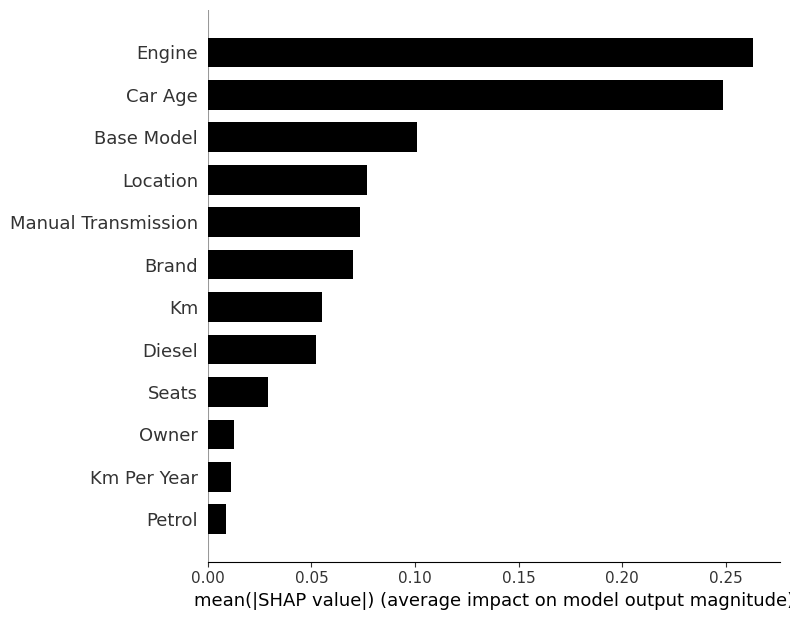

In [58]:
shap.summary_plot(shap_values, X_test, plot_type="bar", color="black")

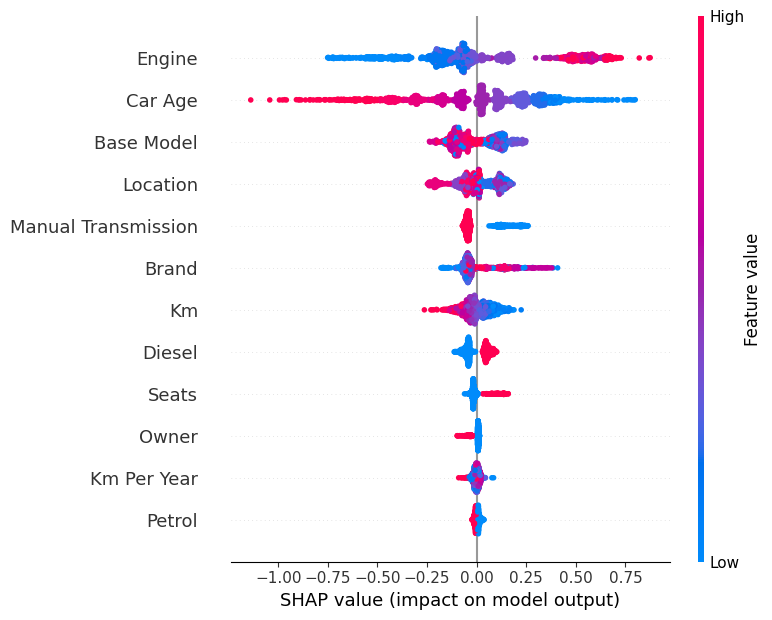

In [59]:
X_test_array = X_test.values.astype(np.float32)

# Recompute shap values on numpy array
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_array)

shap.summary_plot(
    shap_values, 
    X_test_array,
    feature_names=X_test.columns.tolist()
)